In [32]:
### TO RUN
import os

import matplotlib.pyplot as plt
import numpy as np

"Machine learning tools"
import pickle

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier

from src.classification.datasets import Dataset
from src.classification.utils.audio_student import AudioUtil, Feature_vector_DS, MelSpecDataset, SmallCNN
from src.classification.utils.plots import (
    plot_decision_boundaries,
    plot_specgram,
    show_confusion_matrix,
)
from src.classification.utils.utils import accuracy

In [33]:
np.random.seed(0)

Useful functions to select, read and play the dataset sounds are provided in ``classification/utils/audio_student.py``. <br>

As for the H1, you will have to fill some short pieces of code, as well as answer some questions. We already created cells for you to answer the questions to ensure you don't forget it ;). <br>
You will find the zones to be briefly filled  with a ``### TO COMPLETE`` in the cells below.

<font size=6 color=#009999> 2. Training and Evaluating models on audio signals [~1h30-2h] </font> <br>

In [34]:
### TO RUN
dataset = Dataset()
classnames = dataset.list_classes()

print("\n".join(classnames))

background
birds
chainsaw
fire
fireworks
gunshot
handsaw
helicopter


We will only keep 5 class for this notebook:
- birds
- chainsaw
- fire
- handsaw
- helicopter

The classes used in the contest will be different.

In [35]:
dataset.remove_class("background")
dataset.remove_class("fireworks")
dataset.remove_class("gunshot")
classnames = dataset.list_classes()

print("\n".join(classnames))

birds
chainsaw
fire
handsaw
helicopter


In [36]:
### TO RUN
fm_dir = "data/feature_matrices/"  # where to save the features matrices
model_dir = "data/models/"  # where to save the models
os.makedirs(fm_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

In H1, it was not made explicit what we choose as input for the classification model, a.k.a. ``feature vector`` (it was shown in the illustration). <br>
The objective is, on the transmitter side, to compute a feature vector containing enough information about the audio signal we want to classify, but not too much in order to limit the data which has to be transmitted wirelessly. This is why in H1 we implemented the ``Hz2Mel`` conversion: a very simple compression of the frequency content. <br>
The feature vector we will use here simply consists in taking the first 20 columns of the melspectrogram, corresponding to ~1s, then reshaping it as a vector. This means each feature vector contains ``400`` coefficients, with 20 columns of 20 mels each.  <br>

Once the feature vector has been recovered on the receiver side, we can apply any computation on it to guess the right class this sound belongs to. Today, we will simply reuse the simple KNN and LDA classifiers and look at what we already get. 

<font size=3 color=#FF0000> Important :</font> <br>
The analyses that follow are given as food for thoughts. They are not given as step by step improvements of the classifier.

<font size=5 color=#009999> 2.1. Creation of the dataset </font> <br>

``Feature_vector_DS`` is a class defined in ``classification/utils/audio_student.py``. <br>
The functions ``__len__`` and ``__getitem__`` are implemented, meaning you can call :
- ``len(myds)`` to get the number of sounds in it.
- ``myds[classname,j]`` to get the melspectrogram of the ``j``-th sound from class ``classname``. <br>

Two other useful functions are provided:
- ``get_audiosignal`` returning the temporal audiosignal at the specified index.
- ``display`` playing the sound and showing the associated mel-spectrogram at the specified index.

<font size=3 color=#FF0000> Important :</font> <br>
Before being able to run the cells below, you will have to reuse your functions from H1 to fill the missing lines in ``audio_student.py`` at ``###TO COMPLETE`` locations.

Moreover, you have to restart your python kernel for any change to those imported files to be taken into account. This can be done by pressing 》which stops the kernel and tries to run each cell sequentially.

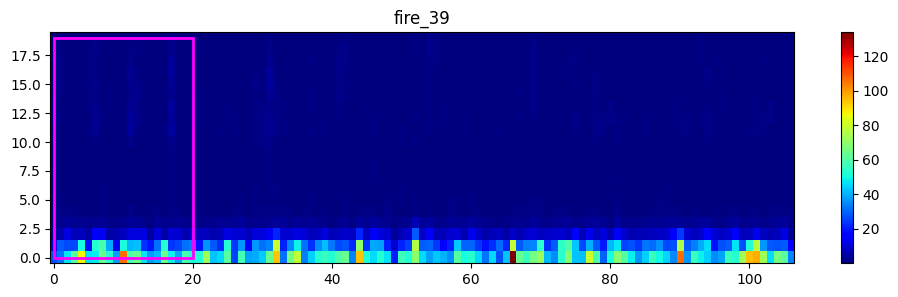

In [37]:
### TO RUN

"Creation of the dataset"
myds = Feature_vector_DS(dataset, Nft=512, nmel=20, duration=950, step=np.inf)

"Some attributes..."
myds.nmel
myds.duration
myds.sr
myds.data_aug
myds.ncol


idx = 39
myds.display(["fire", idx], show_features=True)

### Questions:
The magenta boxes shown in the graph shows the part of the spectrogram that will be actually used as feature.

- Now, in the Feature_vectore_DS intialization, change the step value to 40, 20 and 1. How does this impact the dataset that will be generated?
- Analyze the pros and cons of each value.
- Where can you do your train-test split in each case?

Set step back to np.inf for the rest of this notebook.

In [38]:
### TO RUN
X, y = myds.get_feature_vectors()

np.save(fm_dir + "feature_matrix_2D.npy", X)
np.save(fm_dir + "labels.npy", y)

# X = np.load(fm_dir+"feature_matrix_2D.npy")
# y = np.load(fm_dir+"labels.npy")

print(f"Shape of the feature matrix : {X.shape}")
print(f"Number of labels : {len(y)}")

print(
    "Remember the convention shown for the toy example, the feature vectors are arranged on the rows."
)

Shape of the feature matrix : (200, 400)
Number of labels : 200
Remember the convention shown for the toy example, the feature vectors are arranged on the rows.


In [39]:
"""
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import random

seed = 0
random.seed(seed)                     # Python built-in randomness
np.random.seed(seed)                  # NumPy randomness
torch.manual_seed(seed)               # PyTorch CPU randomness
torch.cuda.manual_seed(seed)          # PyTorch GPU randomness
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- 1. Prepare dataset ---
dataset = MelSpecDataset(myds)

# Extract features and labels
X, y = myds.get_feature_vectors()
X = np.array(X, dtype=np.float32)

# Reshape for CNN (num_samples, 1, n_mels, n_cols)
X = X.reshape(-1, 1, 20, 20)

# Convert string labels to integer labels based on myds.dataset.list_classes()
classnames = myds.dataset.list_classes()
classmap = {name: idx for idx, name in enumerate(classnames)}
y_int = np.array([classmap[label] for label in y], dtype=np.int64)

# Split into training and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_int, test_size=0.3, stratify=y_int, random_state=42
)

# Create DataLoaders
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# --- 2. Define the CNN ---


model = SmallCNN(num_classes=len(classnames))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# --- 3. Train the CNN ---
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        out = model(batch_x)
        loss = criterion(out, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch_x.size(0)  # sum over batch
    total_loss /= len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss = {total_loss:.4f}")

# Save the model
torch.save(model.state_dict(), "cnn_sound_classifier.pth")

# --- 4. Evaluate on test set ---
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        out = model(batch_x)
        pred = torch.argmax(out, dim=1)
        all_preds.extend(pred.numpy())
        all_labels.extend(batch_y.numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# --- 5. Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classnames)
disp.plot(cmap=plt.cm.Blues)
plt.show()
"""

'\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom torch.utils.data import DataLoader, TensorDataset\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport random\n\nseed = 0\nrandom.seed(seed)                     # Python built-in randomness\nnp.random.seed(seed)                  # NumPy randomness\ntorch.manual_seed(seed)               # PyTorch CPU randomness\ntorch.cuda.manual_seed(seed)          # PyTorch GPU randomness\ntorch.backends.cudnn.deterministic = True\ntorch.backends.cudnn.benchmark = False\n\n# --- 1. Prepare dataset ---\ndataset = MelSpecDataset(myds)\n\n# Extract features and labels\nX, y = myds.get_feature_vectors()\nX = np.array(X, dtype=np.float32)\n\n# Reshape for CNN (num_samples, 1, n_mels, n_cols)\nX = X.reshape(-1, 1, 20, 20)\n\n# Convert string labels to integer labels based on myds.datas

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import random

# ============================================================
# 0. Set seed for reproducibility
# ============================================================
# Ensures that results are the same every time this code runs
seed = 0
np.random.seed(seed)               # Seed for numpy random operations
random.seed(seed)                  # Seed for Python random module
torch.manual_seed(seed)            # Seed for CPU operations in PyTorch
torch.cuda.manual_seed(seed)       # Seed for GPU operations in PyTorch
torch.backends.cudnn.deterministic = True  # Makes GPU operations deterministic
torch.backends.cudnn.benchmark = False     # Disable auto-optimization for reproducibility

# ============================================================
# 1. Prepare the dataset
# ============================================================
# Assuming you have a custom dataset class MelSpecDataset that wraps your data
# myds: your raw dataset object
dataset = MelSpecDataset(myds)

# Number of classes in the dataset
num_classes = len(myds.dataset.list_classes())

# Define how many samples per class exist and how many to use for training/testing
num_samples_per_class = 40   # Total samples per class in the dataset
num_train = 32               # First 36 samples per class for training
num_test_extra = 8         # Last 4 samples per class for testing/generalization

# ============================================================
# 2. Create train and test subsets
# ============================================================
# We will manually select indices per class
train_indices = []      # Stores indices for training subset
test_extra_indices = [] # Stores indices for "extra/unseen" test subset

for c in range(num_classes):
    base = c * num_samples_per_class          # Starting index for class c
    all_indices_class = list(range(base, base + num_samples_per_class))  # All indices for this class
    
    # Randomly select indices for testing
    test_indices_class = random.sample(all_indices_class, num_test_extra)
    
    # The remaining indices are for training
    train_indices_class = list(set(all_indices_class) - set(test_indices_class))
    
    train_indices += train_indices_class
    test_extra_indices += test_indices_class
# Create PyTorch Subsets using selected indices
train_dataset_full = MelSpecDataset(myds, data_aug=["add_bg", "noise", "echo", "scaling", "aug_sgram"]) # data augmentation for training
train_dataset = Subset(train_dataset_full, train_indices)         # Training data subset

test_dataset_full = MelSpecDataset(myds, data_aug=None) # no data augmentation for testing
test_extra_dataset = Subset(test_dataset_full, test_extra_indices) # Extra/unseen data subset

# without augmenetation
# train_dataset = Subset(dataset, train_indices)         # Training data subset
# test_extra_dataset = Subset(dataset, test_extra_indices) # Extra/unseen data subset

# Create DataLoaders to batch data and optionally shuffle
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)   # Shuffle for training
test_extra_loader = DataLoader(test_extra_dataset, batch_size=32, shuffle=False) # No shuffle for evaluation
# batch size = number of samples processed before model update (so before the weights are updated trough ADAM optimizer)
# ============================================================
# 3. Define the CNN model
# ============================================================
# Assuming SmallCNN is defined elsewhere
# It should accept num_classes as argument to set output layer size
model = SmallCNN(num_classes=num_classes)

# Optimizer: Adam is popular for CNNs
# ============================================================
# Optimizer: Adam
# ============================================================
# After computing the loss, we need to update the CNN's weights so the loss decreases.
# Adam (Adaptive Moment Estimation) is an advanced optimizer that combines:
# 1. First moment (mean of gradients, like momentum)
# 2. Second moment (uncentered variance of gradients)
# This allows Adam to adapt the learning rate for each parameter individually.

# Benefits of Adam:
# - Handles sparse gradients well
# - Often converges faster than standard SGD
# - Less sensitive to the initial learning rate

# In the code below:
# model.parameters() → all weights and biases of the CNN
# lr=1e-3 → learning rate (step size for weight updates)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Loss function: CrossEntropyLoss combines softmax + negative log-likelihood
# ============================================================
# Loss function: CrossEntropyLoss
# ============================================================
# Measures how wrong the model's predictions are compared to true labels.
# Neural networks output logits (raw scores), not probabilities. 
# CrossEntropyLoss combines:
#   1. Softmax: converts logits to probabilities
#      softmax(z_c) = exp(z_c) / sum_j(exp(z_j))
#   2. Negative Log-Likelihood (NLL):
#      Loss = -sum_c(y_c * log(softmax(z_c)))
#        - y_c = 1 if c is the correct class, 0 otherwise
#        - z_c = logit output by the network for class c

# Why we use it for multi-class classification:
# - Penalizes more when the correct class has low predicted probability
# - Works directly with logits → numerically stable
# - Standard choice for multi-class problems (like audio classification)

# In the code below:
# out → logits from CNN [batch_size, num_classes]
# batch_y → true labels [batch_size], integer indices
criterion = nn.CrossEntropyLoss()

# ============================================================
# 4. Train the CNN
# ============================================================
EPOCHS = 40  # Number of training iterations over the dataset

for epoch in range(EPOCHS):
    model.train()  # Set model to training mode (affects dropout/batchnorm)
    total_loss = 0
    all_preds_train, all_labels_train = [], []  # For computing training accuracy

    # Loop over batches from DataLoader
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()            # Reset gradients before every new batch (optimizer tells how to update weights, so when we start on new data we don't want old gradients to interfere)
        out = model(batch_x)             # Forward pass: compute logits (applies CNN to input batch and produces probabilities for each class)
        loss = criterion(out, batch_y)   # Compute loss (mesures how wrong predictions are)
        loss.backward()                  # Backpropagation: compute gradients (the model calculates how to adjust weights to reduce loss)
        optimizer.step()                 # Update weights based on the computed gradients (the optimizer ADAM modifies the weights slightly in the direction that reduces loss computed at the previous line)
        total_loss += loss.item() * batch_x.size(0)  # Accumulate total loss weighted by batch size

        # Convert logits to predictions
        pred = torch.argmax(out, dim=1)             # chooses the class with the highest score.
        all_preds_train.extend(pred.numpy())      # Store predictions for accuracy
        all_labels_train.extend(batch_y.numpy())  # Store true labels

    # Compute average loss over all training samples
    total_loss /= len(train_loader.dataset)         # total loss divided by number of training samples
    # Compute training accuracy                     
    train_acc = accuracy_score(all_labels_train, all_preds_train)       # number of true labels vs total number of samples
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss = {total_loss:.4f}, Train Accuracy = {train_acc*100:.2f}%")

# Save the trained model for later use
torch.save(model.state_dict(), "cnn_sound_classifier.pth")

# ============================================================
# 5. Confusion matrix on training set
# ============================================================
# Helps visualize which classes the model confuses
cm_train = confusion_matrix(all_labels_train, all_preds_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=myds.dataset.list_classes())
disp_train.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Training Set")
plt.show()

# ============================================================
# 6. Evaluate on last 4 indices per class (generalization check)
# ============================================================
model.eval()  # Set model to evaluation mode (disables dropout/batchnorm)
all_preds_extra, all_labels_extra = [], []  # Store predictions and labels

classnames = myds.dataset.list_classes()   # List of class names

with torch.no_grad():  # Disable gradient computation for evaluation (faster & uses less memory)
    for batch_x, batch_y in test_extra_loader:
        out = model(batch_x)               # Forward pass
        probs = torch.softmax(out, dim=1)  # Convert logits to probabilities
        pred = torch.argmax(probs, dim=1)  # Get predicted class

        # Store predictions and labels
        all_preds_extra.extend(pred.numpy())
        all_labels_extra.extend(batch_y.numpy())

        # Print true label, predicted label, and predicted probabilities for each sample
        for i in range(batch_x.size(0)):
            true_label = classnames[batch_y[i].item()]
            predicted_label = classnames[pred[i].item()]
            prob_values = probs[i].numpy()
            print(f"True: {true_label}, Predicted: {predicted_label}, Probabilities: {prob_values}")

# Compute accuracy on extra/unseen test samples
accuracy_extra = accuracy_score(all_labels_extra, all_preds_extra)
print(f"Accuracy on test data: {accuracy_extra*100:.2f}%")

# Confusion matrix for extra/unseen test samples
cm_extra = confusion_matrix(all_labels_extra, all_preds_extra)
disp_extra = ConfusionMatrixDisplay(confusion_matrix=cm_extra, display_labels=myds.dataset.list_classes())
disp_extra.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on test data")
plt.show()


TypeError: MelSpecDataset.__init__() got an unexpected keyword argument 'data_aug'

--- Fold 1/5 ---
Epoch 1/25, Loss = 1.6084, Train Accuracy = 16.88%
Epoch 2/25, Loss = 1.5763, Train Accuracy = 33.75%
Epoch 3/25, Loss = 1.5459, Train Accuracy = 44.38%
Epoch 4/25, Loss = 1.5073, Train Accuracy = 48.75%
Epoch 5/25, Loss = 1.4478, Train Accuracy = 52.50%
Epoch 6/25, Loss = 1.3730, Train Accuracy = 60.62%
Epoch 7/25, Loss = 1.2793, Train Accuracy = 60.62%
Epoch 8/25, Loss = 1.1847, Train Accuracy = 61.88%
Epoch 9/25, Loss = 1.1067, Train Accuracy = 59.38%
Epoch 10/25, Loss = 1.0424, Train Accuracy = 61.88%
Epoch 11/25, Loss = 0.9770, Train Accuracy = 63.75%
Epoch 12/25, Loss = 0.9127, Train Accuracy = 64.38%
Epoch 13/25, Loss = 0.8620, Train Accuracy = 68.12%
Epoch 14/25, Loss = 0.8291, Train Accuracy = 69.38%
Epoch 15/25, Loss = 0.7775, Train Accuracy = 71.88%
Epoch 16/25, Loss = 0.7566, Train Accuracy = 70.00%
Epoch 17/25, Loss = 0.7235, Train Accuracy = 73.75%
Epoch 18/25, Loss = 0.6727, Train Accuracy = 76.25%
Epoch 19/25, Loss = 0.6577, Train Accuracy = 74.38%
Epoc

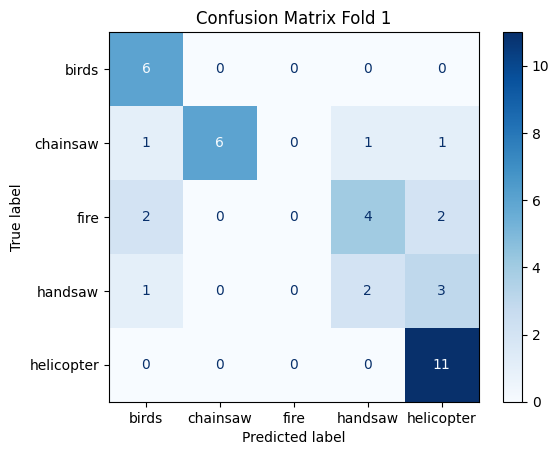

--- Fold 2/5 ---
Epoch 1/25, Loss = 1.6343, Train Accuracy = 10.00%
Epoch 2/25, Loss = 1.5744, Train Accuracy = 34.38%
Epoch 3/25, Loss = 1.5286, Train Accuracy = 46.88%
Epoch 4/25, Loss = 1.4723, Train Accuracy = 51.25%
Epoch 5/25, Loss = 1.3952, Train Accuracy = 54.37%
Epoch 6/25, Loss = 1.2925, Train Accuracy = 56.25%
Epoch 7/25, Loss = 1.1876, Train Accuracy = 53.75%
Epoch 8/25, Loss = 1.0964, Train Accuracy = 55.62%
Epoch 9/25, Loss = 1.0361, Train Accuracy = 56.88%
Epoch 10/25, Loss = 0.9814, Train Accuracy = 60.62%
Epoch 11/25, Loss = 0.9499, Train Accuracy = 61.88%
Epoch 12/25, Loss = 0.9069, Train Accuracy = 61.25%
Epoch 13/25, Loss = 0.8709, Train Accuracy = 60.00%
Epoch 14/25, Loss = 0.8204, Train Accuracy = 68.75%
Epoch 15/25, Loss = 0.7999, Train Accuracy = 68.12%
Epoch 16/25, Loss = 0.7616, Train Accuracy = 72.50%
Epoch 17/25, Loss = 0.7201, Train Accuracy = 72.50%
Epoch 18/25, Loss = 0.6820, Train Accuracy = 75.00%
Epoch 19/25, Loss = 0.6501, Train Accuracy = 75.62%
Epoc

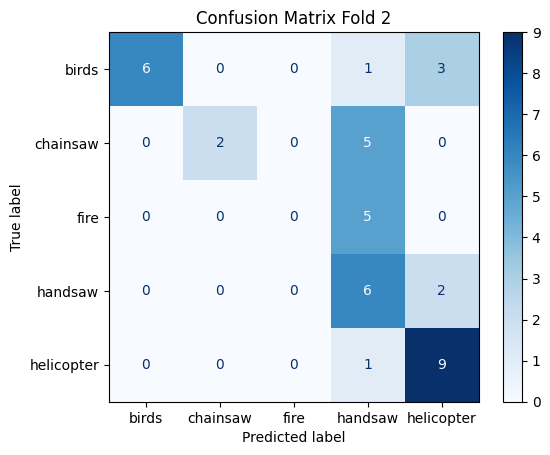

--- Fold 3/5 ---
Epoch 1/25, Loss = 1.6017, Train Accuracy = 20.00%
Epoch 2/25, Loss = 1.5310, Train Accuracy = 43.12%
Epoch 3/25, Loss = 1.4704, Train Accuracy = 43.12%
Epoch 4/25, Loss = 1.3965, Train Accuracy = 48.12%
Epoch 5/25, Loss = 1.3141, Train Accuracy = 50.00%
Epoch 6/25, Loss = 1.2224, Train Accuracy = 55.62%
Epoch 7/25, Loss = 1.1360, Train Accuracy = 58.13%
Epoch 8/25, Loss = 1.0813, Train Accuracy = 56.88%
Epoch 9/25, Loss = 1.0264, Train Accuracy = 56.88%
Epoch 10/25, Loss = 0.9886, Train Accuracy = 59.38%
Epoch 11/25, Loss = 0.9329, Train Accuracy = 60.00%
Epoch 12/25, Loss = 0.8928, Train Accuracy = 66.25%
Epoch 13/25, Loss = 0.8503, Train Accuracy = 63.75%
Epoch 14/25, Loss = 0.8232, Train Accuracy = 63.12%
Epoch 15/25, Loss = 0.7862, Train Accuracy = 65.00%
Epoch 16/25, Loss = 0.7390, Train Accuracy = 67.50%
Epoch 17/25, Loss = 0.7015, Train Accuracy = 72.50%
Epoch 18/25, Loss = 0.6701, Train Accuracy = 68.75%
Epoch 19/25, Loss = 0.6534, Train Accuracy = 73.75%
Epoc

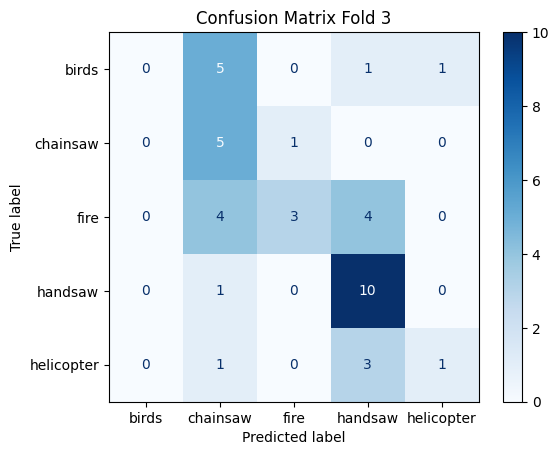

--- Fold 4/5 ---
Epoch 1/25, Loss = 1.5885, Train Accuracy = 20.62%
Epoch 2/25, Loss = 1.5267, Train Accuracy = 38.12%
Epoch 3/25, Loss = 1.4599, Train Accuracy = 38.12%
Epoch 4/25, Loss = 1.3845, Train Accuracy = 43.75%
Epoch 5/25, Loss = 1.3003, Train Accuracy = 52.50%
Epoch 6/25, Loss = 1.2242, Train Accuracy = 50.62%
Epoch 7/25, Loss = 1.1529, Train Accuracy = 55.00%
Epoch 8/25, Loss = 1.0808, Train Accuracy = 61.88%
Epoch 9/25, Loss = 1.0273, Train Accuracy = 62.50%
Epoch 10/25, Loss = 0.9712, Train Accuracy = 65.62%
Epoch 11/25, Loss = 0.9321, Train Accuracy = 62.50%
Epoch 12/25, Loss = 0.8787, Train Accuracy = 65.62%
Epoch 13/25, Loss = 0.8371, Train Accuracy = 68.75%
Epoch 14/25, Loss = 0.8093, Train Accuracy = 70.00%
Epoch 15/25, Loss = 0.7635, Train Accuracy = 70.62%
Epoch 16/25, Loss = 0.7338, Train Accuracy = 71.25%
Epoch 17/25, Loss = 0.7010, Train Accuracy = 72.50%
Epoch 18/25, Loss = 0.6721, Train Accuracy = 73.12%
Epoch 19/25, Loss = 0.6419, Train Accuracy = 73.12%
Epoc

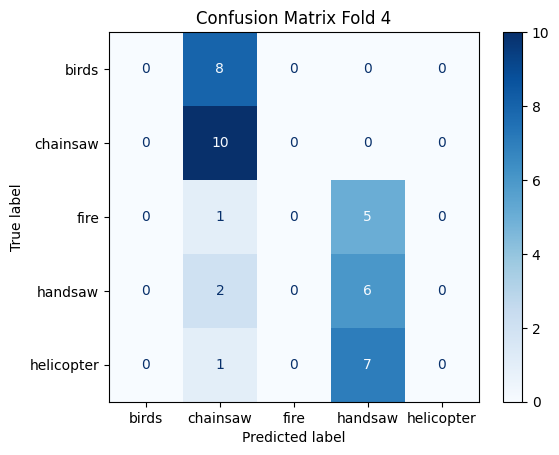

--- Fold 5/5 ---
Epoch 1/25, Loss = 1.6064, Train Accuracy = 24.38%
Epoch 2/25, Loss = 1.5362, Train Accuracy = 38.75%
Epoch 3/25, Loss = 1.4787, Train Accuracy = 35.62%
Epoch 4/25, Loss = 1.4185, Train Accuracy = 38.75%
Epoch 5/25, Loss = 1.3547, Train Accuracy = 43.12%
Epoch 6/25, Loss = 1.2819, Train Accuracy = 46.25%
Epoch 7/25, Loss = 1.2159, Train Accuracy = 49.38%
Epoch 8/25, Loss = 1.1595, Train Accuracy = 51.25%
Epoch 9/25, Loss = 1.1123, Train Accuracy = 56.88%
Epoch 10/25, Loss = 1.0625, Train Accuracy = 60.62%
Epoch 11/25, Loss = 1.0132, Train Accuracy = 58.75%
Epoch 12/25, Loss = 0.9730, Train Accuracy = 60.00%
Epoch 13/25, Loss = 0.9288, Train Accuracy = 62.50%
Epoch 14/25, Loss = 0.8849, Train Accuracy = 66.88%
Epoch 15/25, Loss = 0.8377, Train Accuracy = 68.75%
Epoch 16/25, Loss = 0.7997, Train Accuracy = 70.62%
Epoch 17/25, Loss = 0.7618, Train Accuracy = 71.88%
Epoch 18/25, Loss = 0.7325, Train Accuracy = 72.50%
Epoch 19/25, Loss = 0.6905, Train Accuracy = 70.62%
Epoc

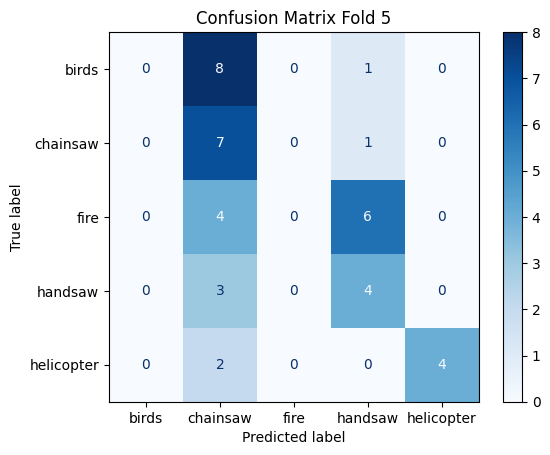

Average Validation Accuracy across 5 folds: 49.00% ± 9.70%


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import random

def normalize_spectrogram(x):
    """
    Normalize a single spectrogram so that it has zero mean and unit variance.
    This removes volume dependency and ensures similar scale across samples.
    x: torch.Tensor of shape [1, height, width] (single-channel spectrogram)
    """
    mean = x.mean()
    std = x.std()
    if std > 0:
        return (x - mean) / std
    else:
        return x - mean  # avoid division by zero

# ============================================================
# 0. Seed for reproducibility
# ============================================================
seed = 0
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================================
# 1. Prepare the dataset
# ============================================================
dataset = MelSpecDataset(myds)
num_classes = len(myds.dataset.list_classes())
classnames = myds.dataset.list_classes()

# ============================================================
# 2. K-Fold Cross-Validation setup
# ============================================================
K = 5  # number of folds
num_samples = len(dataset)
kf = KFold(n_splits=K, shuffle=True, random_state=seed)

fold_idx = 1
fold_accuracies = []

for train_indices, val_indices in kf.split(range(num_samples)):
    print(f"--- Fold {fold_idx}/{K} ---")
    
    # Create train and validation subsets
    train_dataset = Subset(dataset, train_indices)
    val_dataset = Subset(dataset, val_indices)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    # ============================================================
    # 3. Define a fresh CNN for this fold
    # ============================================================
    model = SmallCNN(num_classes=num_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    # ============================================================
    # 4. Train the CNN
    # ============================================================
    EPOCHS = 25
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        all_preds_train, all_labels_train = [], []

        for batch_x, batch_y in train_loader:
            batch_x = torch.stack([normalize_spectrogram(x) for x in batch_x]) # normalize each spectrogram in the batch
            optimizer.zero_grad()
            out = model(batch_x)
            loss = criterion(out, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * batch_x.size(0)

            pred = torch.argmax(out, dim=1)
            all_preds_train.extend(pred.numpy())
            all_labels_train.extend(batch_y.numpy())
        
        total_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(all_labels_train, all_preds_train)
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss = {total_loss:.4f}, Train Accuracy = {train_acc*100:.2f}%")
    
    # ============================================================
    # 5. Evaluate on validation fold
    # ============================================================
    model.eval()
    all_preds_val, all_labels_val = [], []
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            out = model(batch_x)
            probs = torch.softmax(out, dim=1)
            pred = torch.argmax(probs, dim=1)
            
            all_preds_val.extend(pred.numpy())
            all_labels_val.extend(batch_y.numpy())
    
    val_acc = accuracy_score(all_labels_val, all_preds_val)
    fold_accuracies.append(val_acc)
    print(f"Validation Accuracy Fold {fold_idx}: {val_acc*100:.2f}%")
    
    # Confusion matrix for this fold
    cm_val = confusion_matrix(all_labels_val, all_preds_val)
    disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=classnames)
    disp_val.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix Fold {fold_idx}")
    plt.show()
    
    fold_idx += 1

# ============================================================
# 6. Summary across all folds
# ============================================================
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)
print(f"Average Validation Accuracy across {K} folds: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")
